# SUPP-D: Transcript Count Comparison

Per-gene transcript counts for Ensembl vs CAT projections:
density scatter plot and Bland-Altman agreement analysis.

**Input:** `intermediate_spreadsheets/transcript_counts/` from workflow

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
from scipy import stats

RESULTS_DIR = Path('/hps/nobackup/flicek/ensembl/genebuild/jackt/hprc/hprc-qc/results')
TX_DIR = RESULTS_DIR / 'intermediate_spreadsheets' / 'transcript_counts'
OUTPUT_DIR = Path('figures')
OUTPUT_DIR.mkdir(exist_ok=True)

In [2]:
# Load pre-computed data
scatter_df = pd.read_csv(TX_DIR / 'transcript_count_scatter_data.tsv', sep='\t')
per_asm = pd.read_csv(TX_DIR / 'transcript_count_per_assembly.tsv', sep='\t')

print(f"Scatter data: {len(scatter_df):,} gene-assembly pairs")
print(f"Per-assembly data: {len(per_asm)} assemblies")
print(f"\nPer-assembly summary:")
display(per_asm.describe())
print(f"\nScatter data head:")
display(scatter_df.head())

Scatter data: 100,000 gene-assembly pairs
Per-assembly data: 462 assemblies

Per-assembly summary:


,n_rbh_pairs,ens_tx_mean,ens_tx_median,cat_tx_mean,cat_tx_median,mean_difference,correlation,n_exact_count_match,pct_exact_count_match
count,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000,462.000000
mean,75222.320346,4.827381,1.012987,5.184091,1.012987,-0.356818,0.944157,64029.645022,85.037121
std,4207.365808,0.202011,0.113341,0.277345,0.113341,0.120024,0.015020,4766.647757,2.951481
min,39882.000000,4.760000,1.000000,4.910000,1.000000,-0.990000,0.895600,29341.000000,73.300000
25%,75527.750000,4.790000,1.000000,5.130000,1.000000,-0.410000,0.934775,62961.500000,83.760000
50%,75943.500000,4.800000,1.000000,5.170000,1.000000,-0.370000,0.946600,63919.000000,84.295000
75%,76151.500000,4.820000,1.000000,5.210000,1.000000,-0.340000,0.955075,64583.500000,84.880000
max,78425.000000,6.600000,2.000000,7.570000,2.000000,-0.080000,0.979400,72189.000000,92.330000



Scatter data head:


,assembly_accession,ensembl_gene_id,cat_gene_id,n_ensembl_transcripts,n_cat_transcripts,transcript_concordance_rate
0,GCA_042034325.1,gene:ENSG02280010839,HG03742_ha_G0068777,1,1,1.0
1,GCA_018473305.2,gene:ENSG05115053462,HG03453_pa_G0055006,1,1,1.0
2,GCA_042077735.1,gene:ENSG01670063201,HG00290_ha_G0076351,4,4,1.0
3,GCA_042027545.1,gene:ENSG01900025991,HG00609_pa_G0061519,1,1,1.0
4,GCA_042034195.1,gene:ENSG01290051796,HG03742_ha_G0075036,1,1,1.0


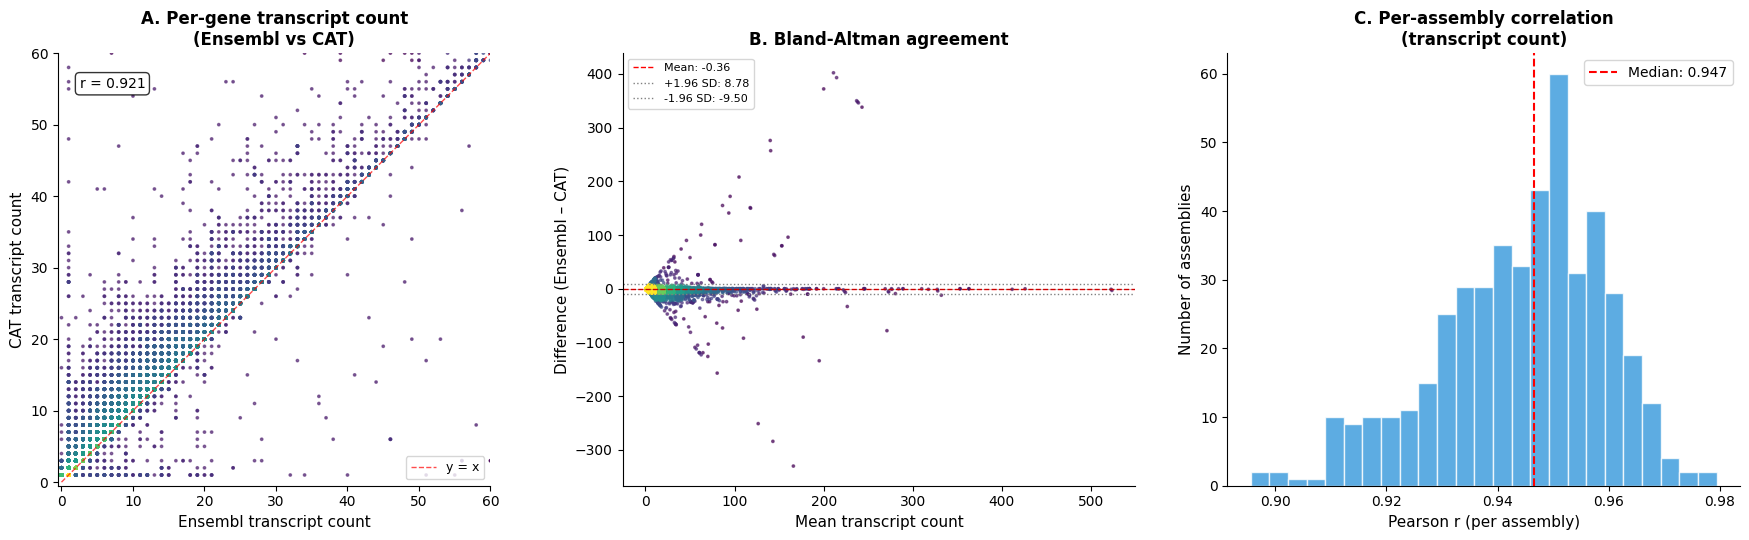

Saved to figures/figure_supp_d_transcript_counts.png


In [3]:
# --- SUPP-D Figure ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

ens = scatter_df['n_ensembl_transcripts'].values
cat = scatter_df['n_cat_transcripts'].values

# ---- Panel A: Density scatter (Ensembl vs CAT transcript count) ----
ax = axes[0]

# 2D histogram for density colouring
max_tx = max(ens.max(), cat.max())
bins = np.arange(0, min(max_tx + 2, 60)) - 0.5  # integer bins, cap at 60
h, xedges, yedges = np.histogram2d(ens, cat, bins=[bins, bins])

# Map each point to its bin density
xi = np.clip(np.digitize(ens, xedges) - 1, 0, len(xedges) - 2)
yi = np.clip(np.digitize(cat, yedges) - 1, 0, len(yedges) - 2)
density = h[xi, yi]

# Sort so densest points are drawn last
order = density.argsort()
ax.scatter(ens[order], cat[order], c=np.log1p(density[order]),
           cmap='viridis', s=3, alpha=0.6, rasterized=True)

# Identity line
lim = min(max_tx + 1, 60)
ax.plot([0, lim], [0, lim], 'r--', lw=1, alpha=0.7, label='y = x')

# Correlation
r, p = stats.pearsonr(ens, cat)
ax.text(0.05, 0.92, f'r = {r:.3f}', transform=ax.transAxes,
        fontsize=10, bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

ax.set_xlabel('Ensembl transcript count', fontsize=11)
ax.set_ylabel('CAT transcript count', fontsize=11)
ax.set_title('A. Per-gene transcript count\n(Ensembl vs CAT)', fontsize=12, fontweight='bold')
ax.set_xlim(-0.5, lim)
ax.set_ylim(-0.5, lim)
ax.set_aspect('equal')
ax.legend(loc='lower right', fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---- Panel B: Bland-Altman plot ----
ax = axes[1]

mean_count = (ens + cat) / 2.0
diff = ens - cat  # positive = Ensembl has more

# Density colouring for Bland-Altman too
ba_bins = 50
h2, xedges2, yedges2 = np.histogram2d(mean_count, diff, bins=ba_bins)
xi2 = np.clip(np.digitize(mean_count, xedges2) - 1, 0, ba_bins - 1)
yi2 = np.clip(np.digitize(diff, yedges2) - 1, 0, ba_bins - 1)
density2 = h2[xi2, yi2]
order2 = density2.argsort()

ax.scatter(mean_count[order2], diff[order2], c=np.log1p(density2[order2]),
           cmap='viridis', s=3, alpha=0.6, rasterized=True)

# Mean difference and limits of agreement
mean_diff = diff.mean()
std_diff = diff.std()
ax.axhline(mean_diff, color='red', ls='--', lw=1, label=f'Mean: {mean_diff:.2f}')
ax.axhline(mean_diff + 1.96 * std_diff, color='grey', ls=':', lw=1,
           label=f'+1.96 SD: {mean_diff + 1.96 * std_diff:.2f}')
ax.axhline(mean_diff - 1.96 * std_diff, color='grey', ls=':', lw=1,
           label=f'-1.96 SD: {mean_diff - 1.96 * std_diff:.2f}')
ax.axhline(0, color='black', ls='-', lw=0.5, alpha=0.3)

ax.set_xlabel('Mean transcript count', fontsize=11)
ax.set_ylabel('Difference (Ensembl \u2013 CAT)', fontsize=11)
ax.set_title('B. Bland-Altman agreement', fontsize=12, fontweight='bold')
ax.legend(fontsize=8, loc='upper left')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# ---- Panel C: Per-assembly correlation distribution ----
ax = axes[2]

corrs = per_asm['correlation'].dropna()
ax.hist(corrs, bins=25, color='#3498db', edgecolor='white', alpha=0.8)
med = corrs.median()
ax.axvline(med, color='red', ls='--', lw=1.5, label=f'Median: {med:.3f}')

ax.set_xlabel('Pearson r (per assembly)', fontsize=11)
ax.set_ylabel('Number of assemblies', fontsize=11)
ax.set_title('C. Per-assembly correlation\n(transcript count)', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(OUTPUT_DIR / 'figure_supp_d_transcript_counts.png', dpi=300, bbox_inches='tight')
fig.savefig(OUTPUT_DIR / 'figure_supp_d_transcript_counts.pdf', bbox_inches='tight')
plt.show()
print(f"Saved to {OUTPUT_DIR / 'figure_supp_d_transcript_counts.png'}")

In [4]:
# Additional summary statistics
pct_exact = (ens == cat).sum() / len(ens) * 100
pct_ens_more = (ens > cat).sum() / len(ens) * 100
pct_cat_more = (cat > ens).sum() / len(ens) * 100

print(f"Exact transcript count match: {pct_exact:.1f}%")
print(f"Ensembl has more transcripts: {pct_ens_more:.1f}%")
print(f"CAT has more transcripts: {pct_cat_more:.1f}%")
print(f"\nMean difference (Ensembl - CAT): {diff.mean():.2f}")
print(f"Median difference: {np.median(diff):.1f}")
print(f"Overall Pearson r: {stats.pearsonr(ens, cat)[0]:.4f}")

# Per-assembly exact match rates
print(f"\nPer-assembly exact match rate:")
print(f"  Mean: {per_asm['pct_exact_count_match'].mean():.1f}%")
print(f"  Median: {per_asm['pct_exact_count_match'].median():.1f}%")
print(f"  Min: {per_asm['pct_exact_count_match'].min():.1f}%")
print(f"  Max: {per_asm['pct_exact_count_match'].max():.1f}%")

Exact transcript count match: 84.9%
Ensembl has more transcripts: 0.6%
CAT has more transcripts: 14.5%

Mean difference (Ensembl - CAT): -0.36
Median difference: 0.0
Overall Pearson r: 0.9211

Per-assembly exact match rate:
  Mean: 85.0%
  Median: 84.3%
  Min: 73.3%
  Max: 92.3%
